# Comparison of PI aerosols using AODVIS (550 nm)

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import tol_colors as tc
import glob

from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec


In [2]:
file_path = "/glade/u/home/jnug/work/multi_PPE_data/annual_means/"
save_dir = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/revisions/figures/"


In [3]:
da_dict = {}

for ppe in ["E3SMv3", "GA7.1", "ECHAM6-HAM", "CAM6"]:
    if ppe == "E3SMv3":
        ext = "_regrid1x1"
    else:
        ext = ""
    da_dict[ppe] = xr.open_dataset(file_path + f"{ppe}_AOD_PI_annual_mean{ext}.nc")["AODVIS_PI"]


In [4]:
# get zonal means
zm_dict = {}

for ppe, da  in da_dict.items():
    zm_dict[ppe] = da.mean(dim="lon")


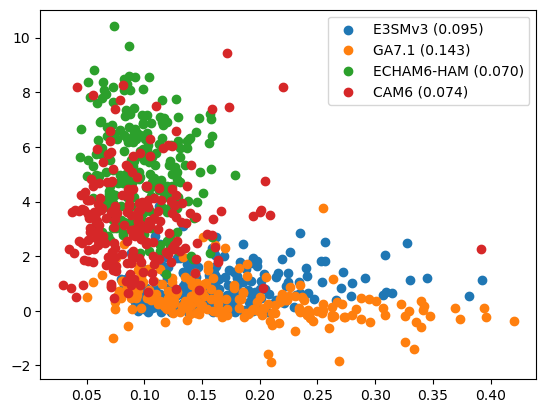

In [5]:
# quick check!
for ppe in list(da_dict.keys()):
    if ppe == "CAM6":
        df = "000"
    else:
        df = 0
    gm_aod = zm_dict[ppe].weighted(np.cos(np.deg2rad(zm_dict[ppe]))).mean(dim="lat")
    gm_dlwp = xr.open_dataset(file_path + f"{ppe}_data_annual_means.nc")["delta_LWP"]
    plt.scatter(gm_aod, gm_dlwp, label=f"{ppe} ({gm_aod.sel(member=df).values:.3f})")

plt.legend()

In [6]:

col_dict = {
    "GA7.1": "#DDAA33",
    "E3SMv3": "#004488",
    "CAM6": "#BB5566", 
    "ECHAM6-HAM": "#228833"
} # from tol-colors "high contrast", plus green


In [13]:
def plot_pi_aod(da_dict, zm_dict, default=True, figsize=(13, 4), legsize=10, fsize=13, col_dict=col_dict,
               vmin=0, vmax=1.5, cmap="Spectral_r", save=False, ylim=(0, 0.3)):
    """ Plot zonal & annual means of PI for either default or ensemble mean
    """

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(3, 3, width_ratios=[2.5, 1, 1], height_ratios=[1, 1, 0.15], hspace=0, wspace=0.1)
    
    ax_zm = plt.subplot(gs[:2, 0])
    ax_cb = plt.subplot(gs[-1, 1:])
    ax_cb.axis("off")
    ax_ins = inset_axes(ax_cb, width="80%", height="80%", loc="center")
    
    proj = ccrs.Mollweide()
    ax_dict = {
        "E3SMv3": plt.subplot(gs[0, 1], projection=proj),
        "GA7.1": plt.subplot(gs[0, 2], projection=proj),
        "CAM6": plt.subplot(gs[1, 1], projection=proj),
        "ECHAM6-HAM": plt.subplot(gs[1, 2], projection=proj)
    }
    
    
    
    for ppe, ax in ax_dict.items():
        if ppe == "GA7.1":
            ppelab = "UKESM1-GA7.1"
        elif ppe == "E3SMv3":
            ppelab = "EAMv3"
        else:
            ppelab = ppe
            
        if default:
            title = "Default"
            if ppe == "CAM6":
                df = "000"
            else:
                df = 0
            aod = da_dict[ppe].sel(member=df)
            zm = zm_dict[ppe].sel(member=df)
        else:
            title = "Ensemble Mean"
            aod = da.mean(dim="member")
            zm = zm_dict[ppe].mean(dim="member")
            
        # spatial plot
        aod_avg = aod.weighted(np.cos(np.deg2rad(aod.lat))).mean(dim=["lat", "lon"])
        ax.set_title(f"{ppelab} ({aod_avg:.3f})", fontsize=fsize)
        pcm = ax.pcolormesh(aod.lon, aod.lat, aod, vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree(), cmap=cmap)
        ax.coastlines()
    
        zm_em = zm_dict[ppe].mean(dim="member")
        zm_std = zm_dict[ppe].std(dim="member")
        ax_zm.plot(zm_em.lat, zm_em, color=col_dict[ppe], label=ppelab, lw=2, zorder=999)
        ax_zm.fill_between(zm_em.lat, zm_em - zm_std, zm_em + zm_std, color=col_dict[ppe], alpha=0.15)
    
    cb = plt.colorbar(pcm, cax=ax_ins, orientation="horizontal", extend="max")
    cb.set_label(f"Annual Mean PI AOD ({title})", fontsize=fsize-2)
    cb.ax.tick_params(labelsize=fsize-2)
    
    ax_zm.set_title(r"Zonal/Annual Mean PI AOD (Ensemble Mean $\pm1\sigma$)",# ({title})", 
                    fontsize=fsize)
    ax_zm.set_ylabel("AOD", fontsize=fsize)
    ax_zm.set_xlabel("Latitude [°]", fontsize=fsize)
    ax_zm.set_ylim(ylim)
    ax_zm.legend(loc="upper right", ncol=1, fontsize=legsize)
    ax_zm.tick_params(which="both", labelsize=fsize-1)
    ax_zm.set_xlim(-90, 90)

    if save:
        plt.savefig(save_dir + f"FigS7_PI_AOD_comparison_{title.lower().replace(" ", "_")}.png", dpi=300, bbox_inches="tight")
    
    plt.show()


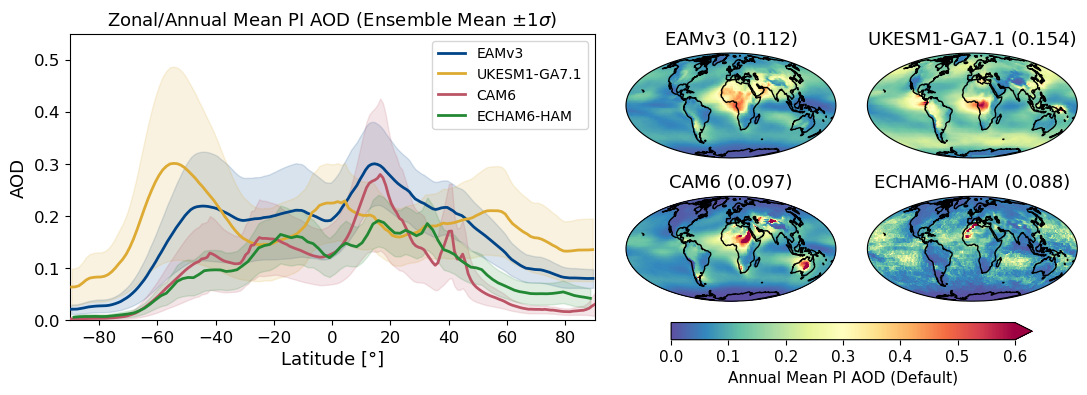

In [14]:
# shading = +/- 1 std, line = ensemble mean
# default for spatial plots

cmap = "Spectral_r"

vmax = 0.6
ylim = (0, 0.55)

plot_pi_aod(da_dict, zm_dict, default=True, vmax=vmax, cmap=cmap, save=True, ylim=ylim)
